In [1]:
library("ape")
library("phytools")
library("scatterplot3d")

Loading required package: maps



In [12]:
tree <- ape::rtree(n = 100) # random phylogeny
x <- c(runif(n = 20), runif(min = 5, max = 10, n = 35), runif(min = 20, max = 25, n = 30), runif(n = 15))
colours <- c(rep("red", 20), rep("orange", 35), rep("blue", 30), rep("green", 15)) # match the groupings in x
y <- x * rnorm(n = 100, mean = 2.5, sd = 1)
z <- x * rnorm(n = 100, mean = 0.5, sd =.751)
traits <- cbind(x, y, z) # the 3D trait space
rownames(traits) <- tree$tip.label # a requirement for the phylomorphospace3d() function

In [48]:
# https://raw.githubusercontent.com/liamrevell/phytools/refs/heads/master/R/phylomorphospace3d.R
# tinkered with function

phylomorphospace3d <- function(tree,X,A=NULL,label=TRUE,control=list(),method="static", ...){
	method<-method[1]
	if(!inherits(tree,"phylo")) stop("tree should be an object of class \"phylo\".")
	# control list
	con=list(spin=TRUE,axes=TRUE,box=TRUE,simple.axes=FALSE,lwd=1,ftype="reg",
		col.edge=rep("black",nrow(tree$edge)))
	con[(namc<-names(control))]<-control
	if(con$simple.axes) con$box<-con$axes<-FALSE
	con$ftype<-which(c("off","reg","b","i","bi")==con$ftype)-1
	if(is.null(A)) A<-apply(X,2,function(x,tree) fastAnc(tree,x),tree=tree)
	else A<-A[as.character(1:tree$Nnode+length(tree$tip)),]
	x<-y<-z<-matrix(NA,nrow(tree$edge),2)
	X<-X[tree$tip.label,]
                            
	for(i in 1:length(tree$tip)){
		x[tree$edge[,2]==i,2]<-X[i,1]
		y[tree$edge[,2]==i,2]<-X[i,2]
		z[tree$edge[,2]==i,2]<-X[i,3]
	}
                            
	for(i in length(tree$tip)+1:tree$Nnode){
		x[tree$edge[,1]==i,1]<-x[tree$edge[,2]==i,2]<-A[as.character(i),1]
		y[tree$edge[,1]==i,1]<-y[tree$edge[,2]==i,2]<-A[as.character(i),2]
		z[tree$edge[,1]==i,1]<-z[tree$edge[,2]==i,2]<-A[as.character(i),3]
	}
	if(is.null(colnames(X))) colnames(X)<-c("x","y","z")
                            
	if(method=="static"){
		# if(hasArg(angle)) angle<-list(...)$angle
		# else angle<-30
		if(hasArg(xlim)) xlim<-list(...)$xlim
		else xlim<-NULL
		if(hasArg(ylim)) ylim<-list(...)$ylim
		else ylim<-NULL
		if(hasArg(zlim)) zlim<-list(...)$zlim
		else zlim=NULL
        
		xx <-scatterplot3d(X,pch=21,xlim=xlim,ylim=ylim,zlim=zlim, grid = TRUE, ...)
		aa<-xx$xyz.convert(A)
        
		for(i in 1:nrow(tree$edge)){
			aa<-xx$xyz.convert(x[i,],y[i,],z[i,])
			lines(aa$x,aa$y,lwd=2,col=con$col.edge[i])
		}
		
        # for(i in 1:length(tree$tip.label)){
		# 	aa<-xx$xyz.convert(x[which(tree$edge[,2]==i),2],y[which(tree$edge[,2]==i),2],
		# 		z[which(tree$edge[,2]==i),2])
		# 	if(con$ftype) text(tree$tip.label[i],x=aa$x,y=aa$y,pos=2,font=con$ftype)
		# }
		invisible(xx)
	}
}

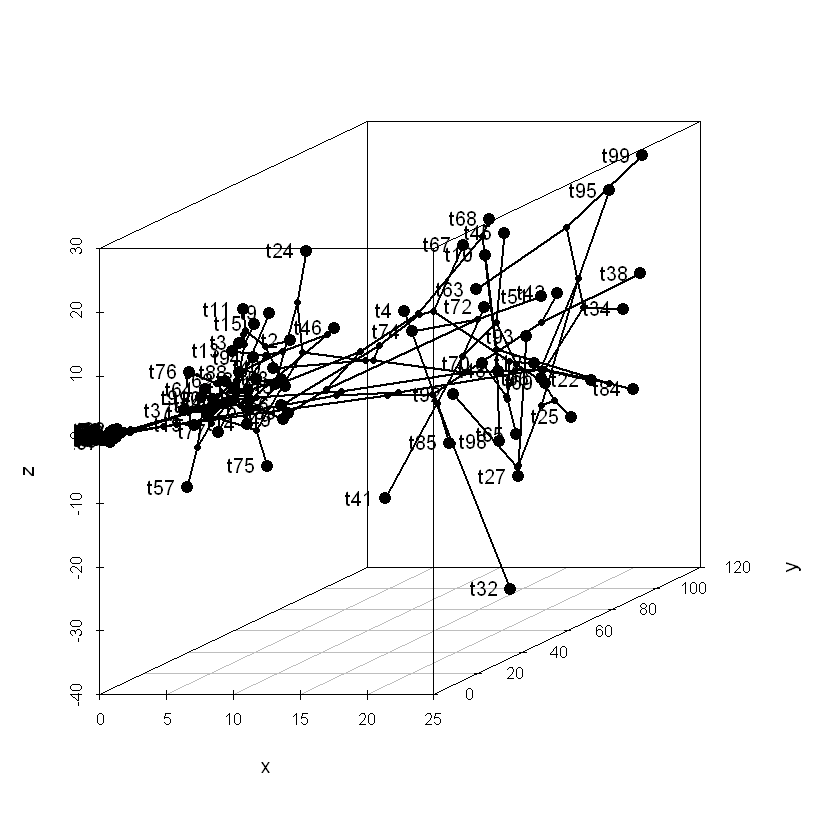

In [49]:
phytools::phylomorphospace3d(tree = tree, X = traits, label = FALSE, method = "static")#, xlab = "T1", ylab = "T2", color = "red")

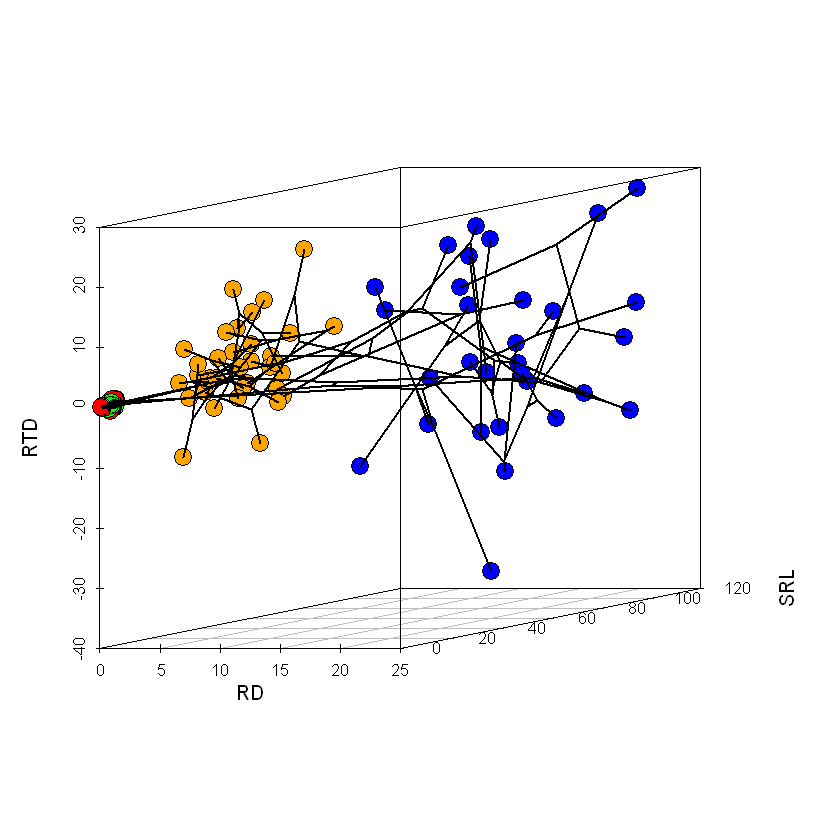

In [62]:
phylomorphospace3d(tree = tree, X = traits, label = FALSE, method = "static", xlab = "RD", ylab = "SRL",
                   zlab = "RTD", bg = colours, cex.symbols = 2, asp = 0.5, angle = 15)

In [71]:
png(filename = "../../plots/3MT-phylomorphospace3D.png", height = 15, width = 15, units = "in", res = 500)
phylomorphospace3d(tree = tree, X = traits, label = FALSE, method = "static", xlab = "RD", ylab = "SRL",
                   zlab = "RTD", bg = colours, cex.symbols = 2, asp = 0.5, angle = 25)
dev.off()

pdf 
  2

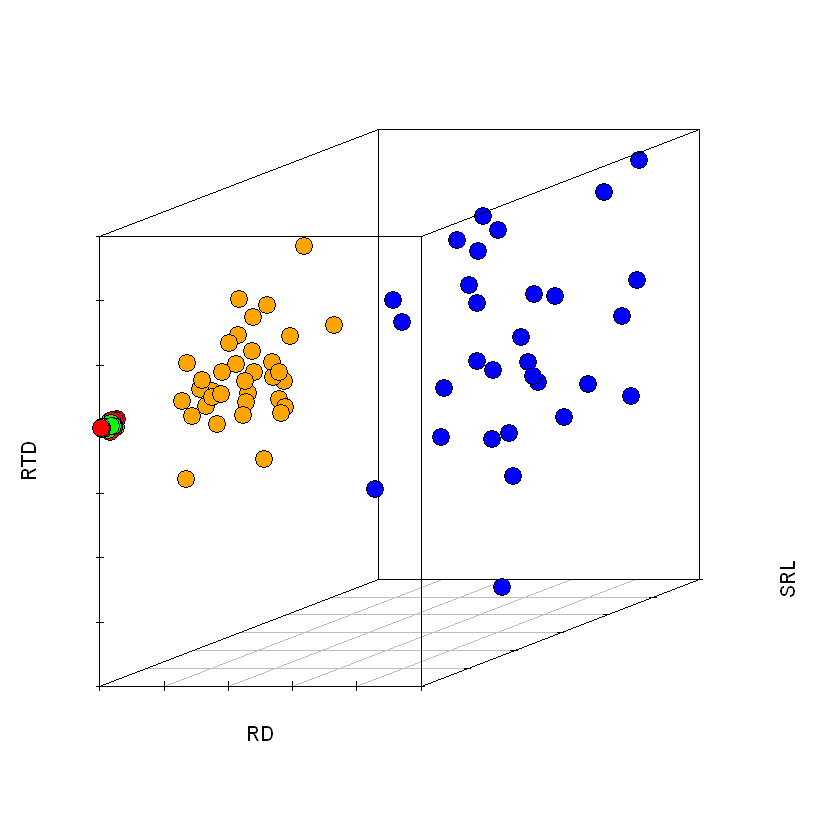

In [70]:
scatterplot3d::scatterplot3d(x = traits, label = FALSE, xlab = "RD", ylab = "SRL",
                   pch = 21, zlab = "RTD", bg = colours, cex.symbols = 2, asp = 0.5, angle = 25)

In [90]:
png(filename = "../../plots/dummy-phylogeny.png", height = 15, width = 25, units = "in", res = 500, bg = "transparent")
plot(ape::rtree(15), show.tip.label = FALSE, show.node.label = FALSE)
dev.off()

pdf 
  2